In [1]:
import mat73
import os 
from tqdm import trange
import numpy as np
import DecayFitNet.python.toolbox.DecayFitNetToolbox as dfn


In [2]:
# load the impulse responses 
srirs = mat73.loadmat("/Users/dalsag1/Documents/datasets/Georg_3room_FDTD/srirs.mat")['srirDataset']

In [3]:
fs = srirs['fs'].item() # sampling frequnecy
L = srirs['srirs'].shape[1] # length of the impulse responses
N = srirs['srirs'].shape[0] # length of the impulse responses
f_bands = [125, 250, 500, 1000, 2000, 4000, 8000]   # frequency bands
model_order = 3 # number of common slopes

In [4]:
# get reference values
common_decay_times = np.zeros((len(f_bands), model_order))
dataset_path = "/Users/dalsag1/Documents/datasets/Georg_3room_FDTD/Common_Slope_Analysis_Results"
for i_band, f_band in enumerate(f_bands):
    filepath = f"cs_analysis_results_omni_{f_band}.mat"
    # read the mat file 
    data = mat73.loadmat(os.path.join(dataset_path, filepath))['analysisResults']
    common_decay_times[i_band, :] = data['commonDecayTimes']
    

In [5]:
# initialize the decay fit net toolbox
dfn_band = dfn.DecayFitNetToolbox(n_slopes=model_order, sample_rate=fs, filter_frequencies=f_bands)
# estimate the parameters 
T_estimated = np.empty((N, len(f_bands), model_order))
A_estimated = np.empty((N, len(f_bands), model_order))
N_estimated = np.empty((N, len(f_bands), 1))
norm_vals = np.empty((N, 1, len(f_bands)))

for i in trange(N, desc='Estimating parameters'):
    ref_rir = srirs['srirs'][i, :, 0]
    current_estimated_param, current_norm_vals = dfn_band.estimate_parameters(ref_rir, analyse_full_rir=True)
    T_estimated[i, :, :] = current_estimated_param[0]
    A_estimated[i, :, :] = current_estimated_param[1]
    N_estimated[i, :, :] = current_estimated_param[2]
    norm_vals[i, :, :] = current_norm_vals

Estimating parameters:   0%|          | 0/838 [00:00<?, ?it/s]/var/folders/3l/7_dsnxg54ngcd4f6xxw46mvr0000gp/T/ipykernel_38258/3538905417.py:15: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  norm_vals[i, :, :] = current_norm_vals
Estimating parameters: 100%|██████████| 838/838 [00:15<00:00, 53.05it/s]


In [6]:
from sklearn.cluster import KMeans

# Initialize an empty list to store the cluster labels for each frequency band
cluster_labels = np.empty((N, len(f_bands), model_order))
cluster_centers = np.empty((model_order, len(f_bands)))
# Perform KMeans clustering for each frequency band
for idx in range(len(f_bands)):
    kmeans = KMeans(n_clusters=model_order )#, random_state=50496)
    T_band = T_estimated[:, idx, :].reshape(-1, 1)
    kmeans.fit(T_band)
    cluster_labels[:, idx, :] = kmeans.labels_.reshape(N, model_order)
    cluster_centers[:, idx] = np.squeeze(kmeans.cluster_centers_)

KeyboardInterrupt: 

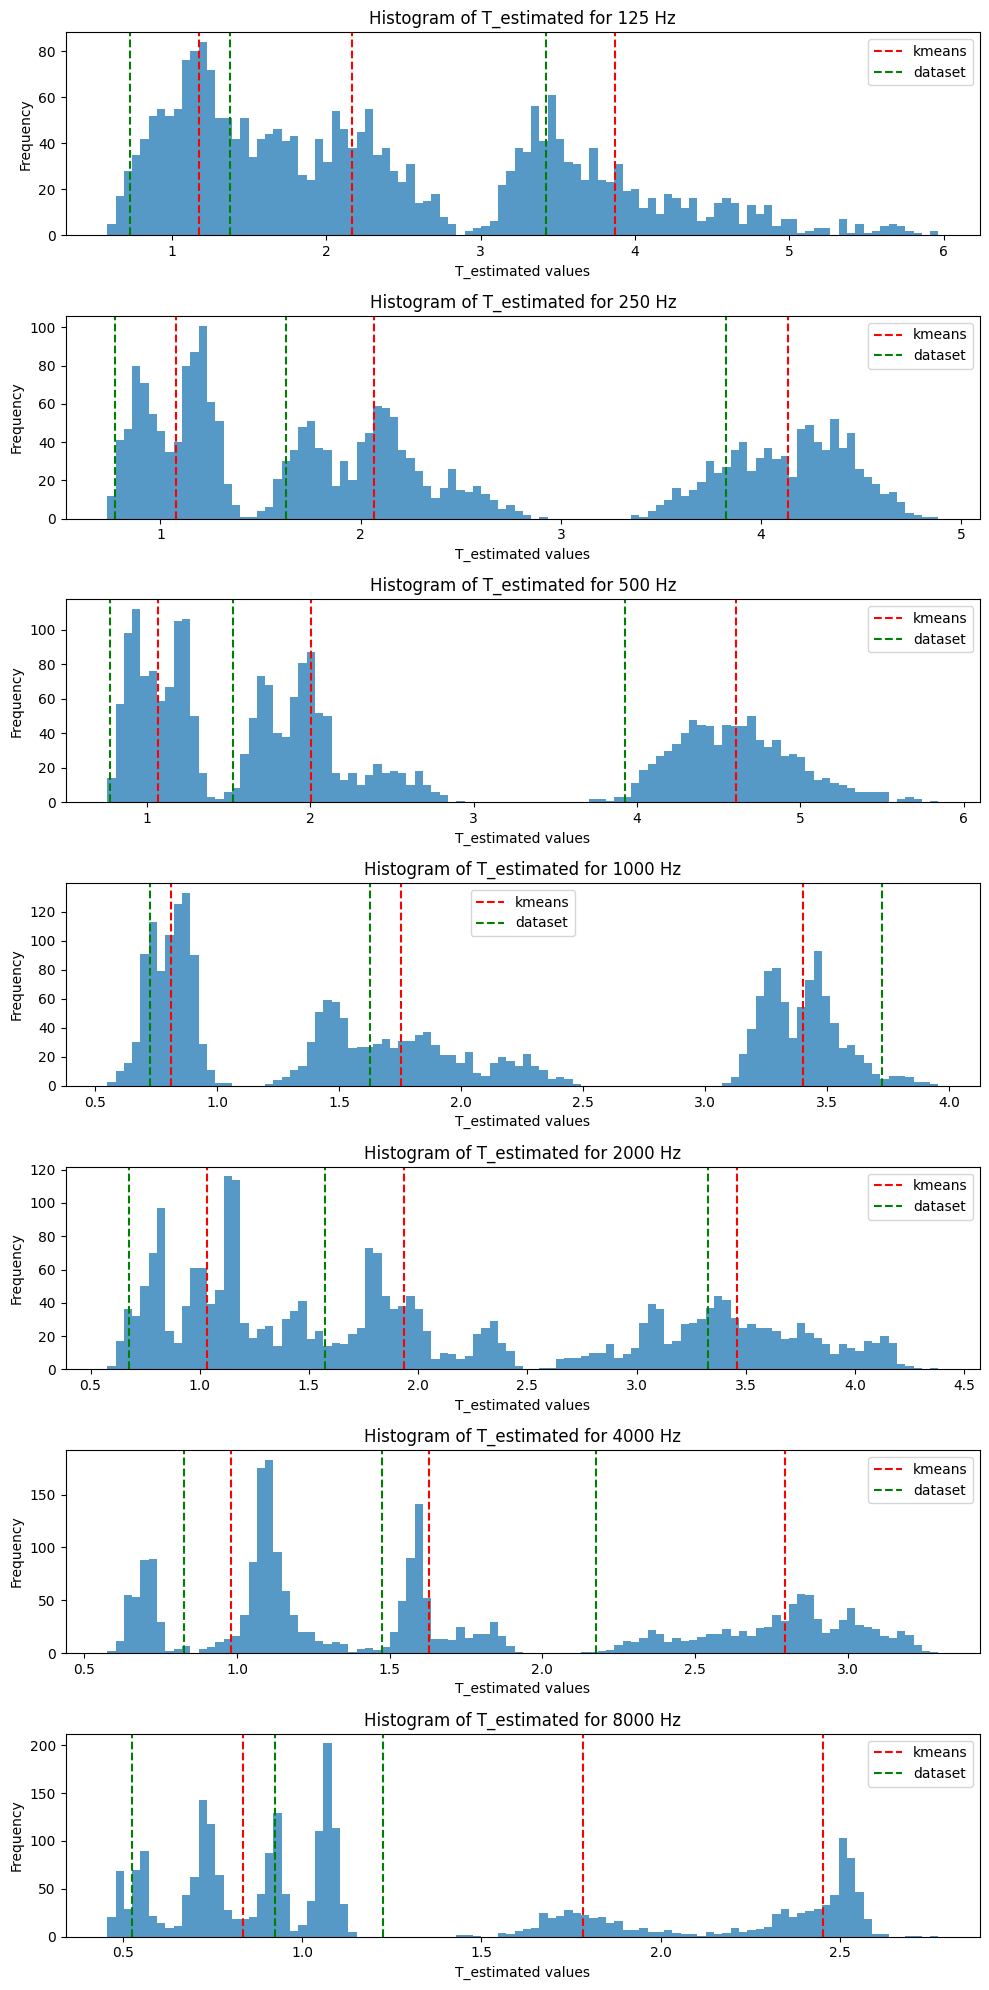

In [11]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(len(f_bands), 1, figsize=(10, 20))

# plot histogram for each frequency band
for idx, ax in enumerate(axes):
    ax.hist(T_estimated[:, idx, :].flatten(), bins=100, alpha=0.75)
    # found with kMeans
    ax.axvline(cluster_centers[0, idx], color='r', linestyle='--', label='kmeans')
    ax.axvline(cluster_centers[1, idx], color='r', linestyle='--')
    ax.axvline(cluster_centers[2, idx], color='r', linestyle='--')
    # given in the dataset
    ax.axvline(common_decay_times[idx, 0], color='g', linestyle='--', label='dataset')
    ax.axvline(common_decay_times[idx, 1], color='g', linestyle='--')
    ax.axvline(common_decay_times[idx, 2], color='g', linestyle='--')
    ax.set_title(f'Histogram of T_estimated for {f_bands[idx]} Hz')
    ax.set_xlabel('T_estimated values')
    ax.set_ylabel('Frequency')
    ax.legend()

plt.tight_layout()
plt.show()